In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.model_selection import GridSearchCV

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving winequality (1) (1).csv to winequality (1) (1).csv


In [ ]:
df = pd.read_csv("/content/winequality (1) (1).csv")

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.shape

(1599, 12)

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [ ]:
df["quality"].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


In [ ]:
corr = df.corr()

corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [ ]:
import numpy as np

df["quality_label"] = np.where(df["quality"]>=7,1,0)

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [ ]:
df["quality_label"].value_counts()

,count
quality_label,
0,1382
1,217


In [ ]:
X = df.drop(["quality","quality_label"],axis=1)

In [ ]:
y = df["quality_label"]

In [ ]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [ ]:
y.head()

,quality_label
0,0
1,0
2,0
3,0
4,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1279, 11)
(320, 11)
(1279,)
(320,)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.859375

In [ ]:
from sklearn.metrics import precision_score

precision_score(y_test,y_pred)

0.55

In [ ]:
from sklearn.metrics import recall_score

recall_score(y_test,y_pred)

0.23404255319148937

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_test,y_pred)

0.3283582089552239

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[264   9]
 [ 36  11]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       273
           1       0.55      0.23      0.33        47

    accuracy                           0.86       320
   macro avg       0.72      0.60      0.62       320
weighted avg       0.83      0.86      0.83       320



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_scaled = LogisticRegression(max_iter=1000)

lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred_scaled = lr_scaled.predict(X_test_scaled)

In [ ]:
print("Accuracy:",accuracy_score(y_test,pred_scaled))

print("Precision:",precision_score(y_test,pred_scaled))

print("Recall:",recall_score(y_test,pred_scaled))

print("F1 Score:",f1_score(y_test,pred_scaled))

Accuracy: 0.865625
Precision: 0.5909090909090909
Recall: 0.2765957446808511
F1 Score: 0.37681159420289856


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "KNN":KNeighborsClassifier(),
    "Decision Tree":DecisionTreeClassifier(random_state=42)
}

for name,model in models.items():

    if name=="Decision Tree":
        model.fit(X_train,y_train)
        pred=model.predict(X_test)

    else:
        model.fit(X_train_scaled,y_train)
        pred=model.predict(X_test_scaled)

    print(name)

    print("Accuracy:",accuracy_score(y_test,pred))

Logistic Regression
Accuracy: 0.865625
KNN
Accuracy: 0.88125
Decision Tree
Accuracy: 0.871875


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid={
    "n_neighbors":[3,5,7,9],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"]
}

grid=GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
grid.best_params_

{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}

In [ ]:
best_model=grid.best_estimator_

prediction=best_model.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,prediction))

Accuracy: 0.921875


In [ ]:
tree=DecisionTreeClassifier(random_state=42)

tree.fit(X_train,y_train)

importance=tree.feature_importances_

In [ ]:
importance_df=pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
})

importance_df=importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
10,alcohol,0.201200
9,sulphates,0.126218
1,volatile acidity,0.110925
3,residual sugar,0.097624
6,total sulfur dioxide,0.092255
5,free sulfur dioxide,0.081969
4,chlorides,0.069198
7,density,0.064104
0,fixed acidity,0.064059
2,citric acid,0.053145


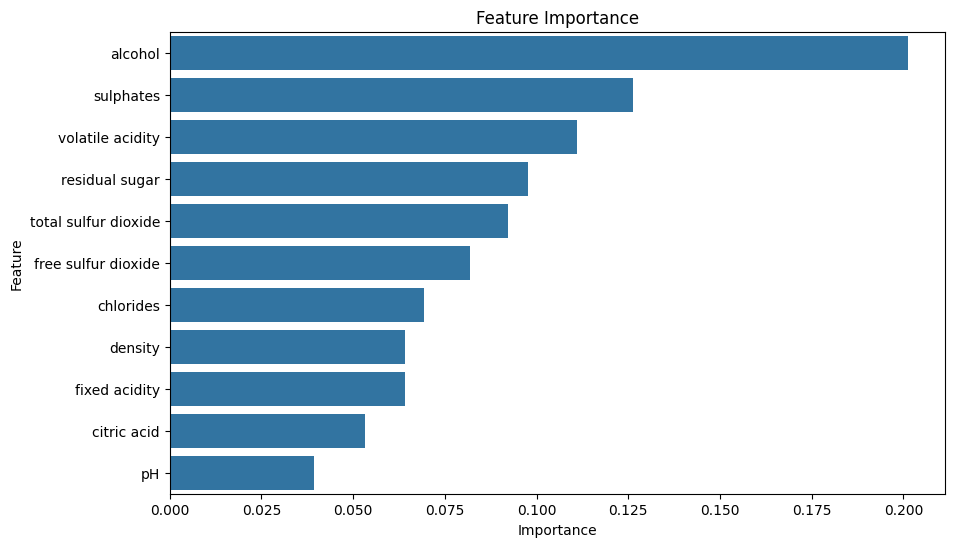

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(data=importance_df,
            x="Importance",
            y="Feature")

plt.title("Feature Importance")

plt.show()

In [ ]:
print(importance_df)

                 Feature  Importance
10               alcohol    0.201200
9              sulphates    0.126218
1       volatile acidity    0.110925
3         residual sugar    0.097624
6   total sulfur dioxide    0.092255
5    free sulfur dioxide    0.081969
4              chlorides    0.069198
7                density    0.064104
0          fixed acidity    0.064059
2            citric acid    0.053145
8                     pH    0.039303


In [ ]:
lr_scaled_pred = lr_scaled.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, lr_scaled_pred)
pre_lr = precision_score(y_test, lr_scaled_pred)
rec_lr = recall_score(y_test, lr_scaled_pred)
f1_lr = f1_score(y_test, lr_scaled_pred)

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, knn_pred)
pre_knn = precision_score(y_test, knn_pred)
rec_knn = recall_score(y_test, knn_pred)
f1_knn = f1_score(y_test, knn_pred)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, dt_pred)
pre_dt = precision_score(y_test, dt_pred)
rec_dt = recall_score(y_test, dt_pred)
f1_dt = f1_score(y_test, dt_pred)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "Accuracy": [acc_lr, acc_knn, acc_dt],
    "Precision": [pre_lr, pre_knn, pre_dt],
    "Recall": [rec_lr, rec_knn, rec_dt],
    "F1 Score": [f1_lr, f1_knn, f1_dt]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.865625,0.590909,0.276596,0.376812
1,KNN,0.881250,0.645161,0.425532,0.512821
2,Decision Tree,0.871875,0.571429,0.510638,0.539326


In [ ]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print(best_model)

Model             KNN
Accuracy      0.88125
Precision    0.645161
Recall       0.425532
F1 Score     0.512821
Name: 1, dtype: object


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best Cross Validation Accuracy: 0.893670343137255


In [ ]:
best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.921875
Precision: 0.7894736842105263
Recall: 0.6382978723404256
F1 Score: 0.7058823529411765
